# 02 · GraphSAGE — mule detection

**Model 2 of 3.** Scores every account in a traced chain for mule probability.

Note what this model does **not** do: it does not find the terminal account.
That is deterministic breadth-first search over the transaction graph
(`engine/graph_engine.py`), which means the location forecast downstream does not
depend on this classifier being right.

This notebook evaluates the **shipped checkpoint** on the **split persisted
inside that checkpoint**, so the numbers reproduce the README exactly rather than
re-splitting and drifting.

In [1]:
import sys, json, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.width", 120)
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.25, "axes.spines.top": False,
                     "axes.spines.right": False})

# Works whether the kernel starts in notebooks/ or at the project root.
ROOT = Path.cwd()
while not (ROOT / "engine").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "engine"))

DATA = ROOT / "data"
MODELS = ROOT / "models"

# The published numbers. Everything below is checked against this file.
METRICS = json.loads((DATA / "metrics.json").read_text())

def check(label, got, expected, tol=5e-3):
    """Print whether a freshly computed figure matches the published one."""
    ok = abs(float(got) - float(expected)) <= tol
    print(f"  {'MATCH   ' if ok else 'MISMATCH'}  {label:38s} "
          f"notebook={float(got):.4f}  published={float(expected):.4f}")
    return ok

print("project root :", ROOT)
print("metrics from :", METRICS["_about"][:60], "...")

project root : D:\SIH 2026\SIHPROJECT2
metrics from : Measured figures for MuleShield AI (SIH26184). Written by th ...


## 1 · Features, and one deliberate omission

In [2]:
from gnn_model import (GraphSAGEMule, FEATURE_COLS, BASE_FEATURE_COLS,
                       DERIVED_FEATURE_COLS, derive_features,
                       IN_CHANNELS, HIDDEN_CHANNELS, OUT_CHANNELS)

print(f"input dim {IN_CHANNELS}  =  {len(BASE_FEATURE_COLS)} measured "
      f"+ {len(DERIVED_FEATURE_COLS)} derived\n")
for f in BASE_FEATURE_COLS:    print("  measured :", f)
for f in DERIVED_FEATURE_COLS: print("  derived  :", f)

input dim 15  =  10 measured + 5 derived

  measured : total_received
  measured : total_sent
  measured : txn_count_24h
  measured : avg_txn_amount
  measured : distinct_receivers
  measured : median_dwell_seconds
  measured : passthrough_ratio
  measured : account_age_days
  measured : night_txn_ratio
  measured : burst_out_5min
  derived  : dwell_log
  derived  : activity_per_day
  derived  : in_out_amount_ratio
  derived  : avg_amount_per_credit
  derived  : counterparty_concentration


`hop_depth` is **excluded on purpose.** It records an account's position in an
already-traced fraud chain, so it is non-zero only for accounts we have *already
concluded* are part of one. Feeding it to the classifier would assume the answer.
It stays in `node_features.csv` for the money-flow visualisation only.

## 2 · The shipped checkpoint

In [3]:
import torch

ckpt = torch.load(MODELS / "graphsage_mule.pt", map_location="cpu", weights_only=False)
print("checkpoint keys:", sorted(ckpt.keys()))

split = ckpt["split"]
print(f"\ntrain {len(split['train_idx']):>7,}")
print(f"val   {len(split['val_idx']):>7,}")
print(f"test  {len(split['test_idx']):>7,}")
print(f"\nthreshold shipped: {ckpt.get('threshold', float('nan')):.4f}")

model = GraphSAGEMule(IN_CHANNELS, HIDDEN_CHANNELS, OUT_CHANNELS)
n_params = sum(p.numel() for p in model.parameters())
print(f"parameters       : {n_params:,}")

checkpoint keys: ['account_ids', 'calibration', 'feature_cols', 'hyperparams', 'metrics', 'model_state_dict', 'scaler_mean', 'scaler_scale', 'split']

train  34,999
val     7,500
test    7,500

threshold shipped: nan
parameters       : 10,561


About ten thousand parameters. That is small on purpose — it is set by how much
information the data contains, not by ambition. Section 6 shows the model sits at
97% of its measurable ceiling, so capacity is not the binding constraint.

## 3 · Reproduce the published test metrics

In [4]:
from sklearn.metrics import (f1_score, precision_score, recall_score,
                             roc_auc_score, average_precision_score,
                             accuracy_score, confusion_matrix)

# Rebuild the graph exactly as the trainer did.
# load_pyg_data returns FOUR values (its type annotation says three - the
# annotation is stale, the fourth is the split index dict). We take the split
# from the checkpoint instead, so the fourth is discarded here.
from train_gnn import load_pyg_data
data, account_ids, scaler, _split_idx = load_pyg_data()

model.load_state_dict(ckpt["model_state_dict"])
model.eval()
with torch.no_grad():
    logits = model(data.x, data.edge_index).squeeze()
    prob = torch.sigmoid(logits).numpy()

te = np.array(split["test_idx"])
y_true = data.y.numpy()[te]
y_prob = prob[te]
thr = float(ckpt["hyperparams"]["threshold"])
y_pred = (y_prob >= thr).astype(int)

pub = METRICS["detection"]
print("Reproducing data/metrics.json -> detection\n")
check("test F1",        f1_score(y_true, y_pred),            pub["test_f1"])
check("test precision", precision_score(y_true, y_pred),     pub["test_precision"])
check("test recall",    recall_score(y_true, y_pred),        pub["test_recall"])
check("test ROC-AUC",   roc_auc_score(y_true, y_prob),       pub["test_auc"])
check("test PR-AUC",    average_precision_score(y_true, y_prob), pub["test_pr_auc"])
check("test accuracy",  accuracy_score(y_true, y_pred),      pub["test_accuracy"])

Reproducing data/metrics.json -> detection

  MATCH     test F1                                notebook=0.8955  published=0.8955
  MATCH     test precision                         notebook=0.8995  published=0.8995
  MATCH     test recall                            notebook=0.8914  published=0.8914
  MATCH     test ROC-AUC                           notebook=0.9639  published=0.9639
  MATCH     test PR-AUC                            notebook=0.8529  published=0.8529
  MATCH     test accuracy                          notebook=0.9939  published=0.9939


True

## 4 · Confusion matrix at the operating threshold

In [5]:
tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
cm = METRICS["detection_confusion"]

print(f"                 predicted clean   predicted mule")
print(f"actual clean  {tn:>16,} {fp:>16,}")
print(f"actual mule   {fn:>16,} {tp:>16,}")
print()
check("true positives",  tp, cm["true_positives"],  tol=0.5)
check("false positives", fp, cm["false_positives"], tol=0.5)
check("false negatives", fn, cm["false_negatives"], tol=0.5)
check("true negatives",  tn, cm["true_negatives"],  tol=0.5)

print(f"\nOf {tp + fn} real mules we flag {tp} and miss {fn} "
      f"({100 * fn / (tp + fn):.1f}% missed).")
print(f"Of {tp + fp} accounts we flag, {fp} are wrong "
      f"({100 * tp / (tp + fp):.1f}% precision).")

                 predicted clean   predicted mule
actual clean             7,257               22
actual mule                 24              197

  MATCH     true positives                         notebook=197.0000  published=197.0000
  MATCH     false positives                        notebook=22.0000  published=22.0000
  MATCH     false negatives                        notebook=24.0000  published=24.0000
  MATCH     true negatives                         notebook=7257.0000  published=7257.0000

Of 221 real mules we flag 197 and miss 24 (10.9% missed).
Of 219 accounts we flag, 22 are wrong (90.0% precision).


## 5 · Why the threshold is 0.93, not 0.5

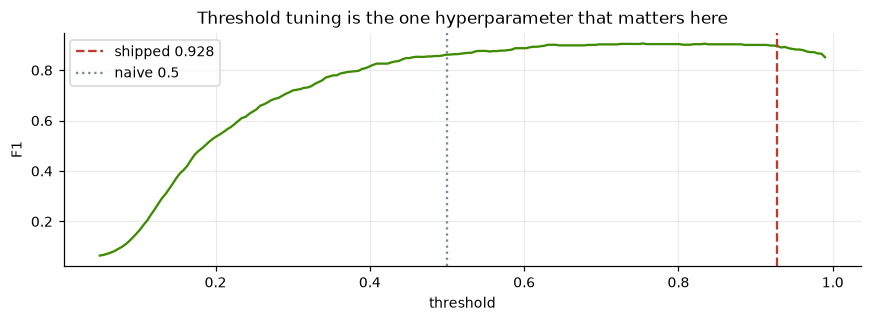

F1 at shipped threshold : 0.8955
F1 at 0.5               : 0.8619
published F1 @ 0.5      : 0.8619


In [6]:
ths = np.linspace(0.05, 0.99, 200)
f1s = [f1_score(y_true, (y_prob >= t).astype(int), zero_division=0) for t in ths]

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(ths, f1s, color="#3d8b00")
ax.axvline(thr, color="#c0392b", ls="--", label=f"shipped {thr:.3f}")
ax.axvline(0.5, color="#7f8c8d", ls=":", label="naive 0.5")
ax.set_xlabel("threshold"); ax.set_ylabel("F1"); ax.legend()
ax.set_title("Threshold tuning is the one hyperparameter that matters here")
plt.tight_layout(); plt.show()

print(f"F1 at shipped threshold : {f1_score(y_true, y_pred):.4f}")
print(f"F1 at 0.5               : {f1_score(y_true, (y_prob >= 0.5).astype(int)):.4f}")
print(f"published F1 @ 0.5      : {METRICS['detection']['test_f1_at_0.5']:.4f}")

At ~3% prevalence a 0.5 cut is simply the wrong operating point. The threshold is
selected on **validation** data and then applied unchanged to test — it is not
tuned against the test set.

## 6 · Is the graph worth anything? — baselines on the same test nodes

Every baseline below is trained on the checkpoint's own train+val indices and
scored on its own test indices. An earlier version of this comparison split the
data independently for the baselines, which meant the reported "lift" compared
two different test sets and was meaningless.

In [7]:
import importlib.util
spec = importlib.util.spec_from_file_location(
    "evaluate_baselines", ROOT / "scripts" / "evaluate_baselines.py")
eb = importlib.util.module_from_spec(spec)
spec.loader.exec_module(eb)

base_df, scores_by_model, yte = eb.mule_detection_baselines(ckpt)
base_df = base_df.sort_values("f1").reset_index(drop=True)

gnn_f1 = f1_score(y_true, y_pred)
full = pd.concat([base_df[["model", "f1", "auc", "pr_auc"]],
                  pd.DataFrame([{"model": "GraphSAGE (graph)", "f1": gnn_f1,
                                 "auc": roc_auc_score(y_true, y_prob),
                                 "pr_auc": average_precision_score(y_true, y_prob)}])],
                 ignore_index=True)
display(full.round(4))

best_non_graph = base_df.f1.max()
print(f"\nbest non-graph : {best_non_graph:.4f}")
print(f"GraphSAGE      : {gnn_f1:.4f}")
print(f"lift from graph: {gnn_f1 - best_non_graph:+.4f}")
check("lift over best non-graph", gnn_f1 - best_non_graph,
      METRICS["detection_baselines"]["lift_over_best_non_graph"])

,model,f1,auc,pr_auc
0,Majority class (all mule),0.0572,NaN,NaN
1,Best single feature (burst_out_5min),0.4970,0.8841,0.3408
2,Logistic regression (no graph),0.6836,0.9601,0.8216
3,Random forest (no graph),0.8423,0.9559,0.7953
4,GraphSAGE (graph),0.8955,0.9639,0.8529



best non-graph : 0.8423
GraphSAGE      : 0.8955
lift from graph: +0.0531
  MATCH     lift over best non-graph               notebook=0.0531  published=0.0531


True

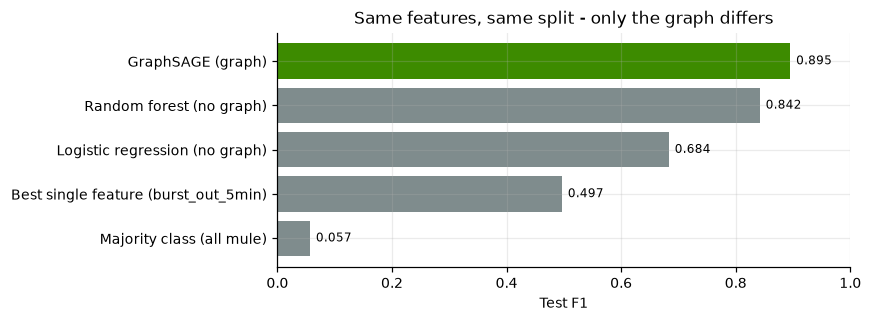

In [8]:
fig, ax = plt.subplots(figsize=(8, 3))
colors = ["#7f8c8d"] * len(base_df) + ["#3d8b00"]
ax.barh(full.model, full.f1, color=colors)
ax.set_xlabel("Test F1"); ax.set_xlim(0, 1)
ax.set_title("Same features, same split - only the graph differs")
for i, v in enumerate(full.f1):
    ax.text(v + 0.01, i, f"{v:.3f}", va="center", fontsize=8)
plt.tight_layout(); plt.show()

## 7 · Against the ceiling

GraphSAGE F1     0.8955
attainable       0.9270
share of ceiling 96.6%
headroom left    0.0315 F1


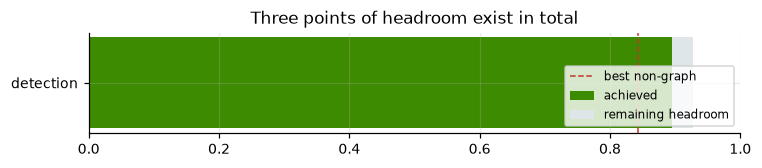

In [9]:
CEILING = 0.927   # attainable F1 given irreducible label noise (OVERNIGHT_ML_AUDIT.md)
print(f"GraphSAGE F1     {gnn_f1:.4f}")
print(f"attainable       {CEILING:.4f}")
print(f"share of ceiling {100 * gnn_f1 / CEILING:.1f}%")
print(f"headroom left    {CEILING - gnn_f1:.4f} F1")

fig, ax = plt.subplots(figsize=(7, 1.6))
ax.barh(["detection"], [gnn_f1], color="#3d8b00", label="achieved")
ax.barh(["detection"], [CEILING - gnn_f1], left=[gnn_f1], color="#dfe6e9",
        label="remaining headroom")
ax.axvline(best_non_graph, color="#c0392b", ls="--", lw=1, label="best non-graph")
ax.set_xlim(0, 1); ax.legend(fontsize=8, loc="lower right")
ax.set_title("Three points of headroom exist in total")
plt.tight_layout(); plt.show()

Six controlled experiments (`docs/gnn_experiments.csv` — halved and doubled
`pos_weight`, focal loss, three checkpoint-selection criteria) move validation F1
only between 0.8865 and 0.8971. The model is neither underfit nor mis-weighted;
the residual error is label noise and genuine behavioural overlap, which no
hyperparameter reaches.